In [1]:
import sys
if 'google.colab' in sys.modules:
  !pip install -q git+https://github.com/nuru-nu/nucas#egg=nucas[colab]

In [2]:
import nucas

2025-07-06 16:54:59,615 - INFO - Using backend: torch
2025-07-06 16:55:00,403 - INFO - Apple Metal (MPS) available, using GPU


In [3]:
nucas.notebook.init()

2025-07-06 16:55:00,607 - WARNING - Google Drive can only be mounted in Colab.


In [4]:
# load db from Drive
db = nucas.db.get_db()
db.df

2025-07-06 16:55:01,404 - INFO - Loaded db from /Users/andstein/ncas: 7 entries


,batch_size,crop,crop_region,group,id,lr,model_name,name,notes,overflow_loss,parent,pool_size,rollout_max,rollout_min,steps,sz,target,update_rate
0,4,1.0,NaN,NaN,20250616_234308,0.001,CaOrig,NaN,NaN,True,NaN,1024,64,32,2,128,https://www.robots.ox.ac.uk/~vgg/data/dtd/imag...,0.5
1,4,1.0,NaN,NaN,20250616_234355,0.001,CaOrig,NaN,NaN,True,NaN,1024,64,32,2,128,https://www.robots.ox.ac.uk/~vgg/data/dtd/imag...,0.5
2,4,1.0,NaN,NaN,20250617_000528,0.001,CaOrig,NaN,NaN,True,NaN,1024,64,32,2,128,https://www.robots.ox.ac.uk/~vgg/data/dtd/imag...,0.5
3,4,1.0,NaN,NaN,20250617_001644,0.001,CaOrig,NaN,NaN,True,NaN,1024,64,32,2,128,https://www.robots.ox.ac.uk/~vgg/data/dtd/imag...,0.5
4,4,1.0,NaN,NaN,20250617_002139,0.001,CaOrig,NaN,NaN,True,NaN,1024,64,32,2,128,https://www.robots.ox.ac.uk/~vgg/data/dtd/imag...,0.5
5,4,1.0,NaN,NaN,20250617_002905,0.001,CaOrig,NaN,NaN,True,NaN,1024,64,32,2,128,https://www.robots.ox.ac.uk/~vgg/data/dtd/imag...,0.5
6,4,1.0,"[1187, 2298, 1767, 2908]",NaN,20250705_224943,0.001,CaOrig,NaN,brown hair,True,NaN,1024,64,32,1000,128,https://unsplash.com/photos/eBomgaTJ1oI/download,0.5



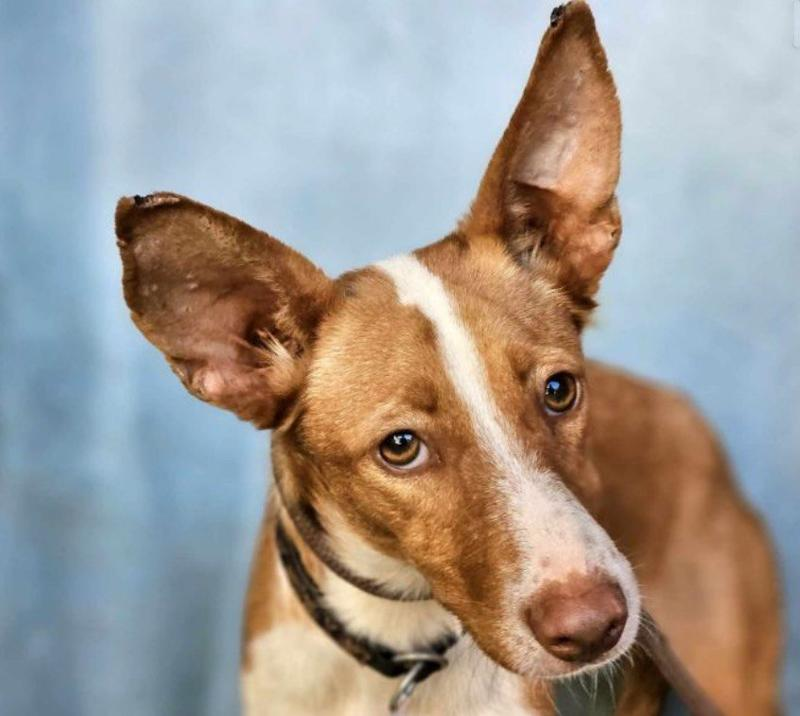

In [5]:
# UI that let's you select "crop_region" ...
nucas.notebook.RegionSelector('https://files.catbox.moe/n7hbrl.jpg')

In [6]:
config = nucas.train.get_config()
# ... for copy'n'paste here
config.target = "https://files.catbox.moe/n7hbrl.jpg"
config.crop_region = [386,438,471,522]
config.notes = 'right eye of ima'

config

batch_size: 4
crop: 1.0
crop_region:
- 386
- 438
- 471
- 522
group: ''
id: ''
lr: 0.001
model: {}
model_name: CaOrig
name: ''
notes: right eye of ima
overflow_loss: true
parent: ''
pool_size: 1024
rollout_max: 64
rollout_min: 32
steps: 1000
sz: 128
target: https://files.catbox.moe/n7hbrl.jpg
update_rate: 0.5

In [14]:
config.steps = 5

In [15]:
# trains in ~5 minutes on a T4
model, stats = nucas.train.train(config)

  0%|          | 0/5 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1.2 seconds - 4.2 steps/sec


In [8]:
imgs = nucas.run.run(config, model)

import mediapy
mediapy.show_video(imgs)

This browser does not support the video tag.


In [9]:
# store model in database
db.save(config, model, stats, imgs)
# -> this is the id to use it later (e.g. for grafting)
config.id

'20250705_224943'